In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Global Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.autolayout": True
})


In [2]:
# 1. LOAD & COMBINE CSV FILES
years = [2021, 2022, 2023, 2024, 2025]
frames = []

for yr in years:
    df = pd.read_csv(f"MLB_{yr}_stats.csv")
    df["Season"] = yr
    frames.append(df)
    print(f"  {yr}: {len(df)} team rows loaded")

mlb = pd.concat(frames, ignore_index=True)

# Rename for clarity and compute RD
mlb = mlb.rename(columns={"Tm": "Team", "W-L%": "WL_Pct", "OPS+": "OPS_plus"})
mlb["RD"] = mlb["RS"] - mlb["RA"]

print(f"\nCombined dataset: {mlb.shape[0]} rows × {mlb.shape[1]} columns")

  2021: 30 team rows loaded
  2022: 30 team rows loaded
  2023: 30 team rows loaded
  2024: 30 team rows loaded
  2025: 30 team rows loaded

Combined dataset: 150 rows × 9 columns


In [3]:
# 2. PRINTED DATAFRAME — FULL DATASET
key_cols = ["Team", "Season", "OPS_plus", "TB", "WAR", "WL_Pct", "RS", "RD"]

print("FULL MERGED DATASET (sorted by Season, then Team)")
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
full_dataset = mlb[key_cols].sort_values(["Season", "Team"])
print(full_dataset.to_string(index=False))
full_dataset.to_csv("mlb_full_dataset.csv", index=False)
print("\n  Saved: mlb_full_dataset.csv")

FULL MERGED DATASET (sorted by Season, then Team)
                 Team  Season  OPS_plus   TB    WAR  WL_Pct  RS   RD
 Arizona Diamondbacks    2021        87 2099  9.400   0.321 679 -214
       Atlanta Braves    2021        98 2333 21.100   0.547 790  134
    Baltimore Orioles    2021        92 2177  9.800   0.321 659 -297
       Boston Red Sox    2021       106 2467 24.400   0.568 829   80
         Chicago Cubs    2021        93 2162 18.300   0.438 705 -134
    Chicago White Sox    2021       106 2262 23.500   0.574 796  160
      Cincinnati Reds    2021        95 2339 12.000   0.512 786   26
  Cleveland Guardians    2021        94 2170 16.200   0.494 717  -10
     Colorado Rockies    2021        86 2227 20.300   0.460 739  -57
       Detroit Tigers    2021        96 2146  9.500   0.475 697  -59
       Houston Astros    2021       113 2486 35.500   0.586 863  205
   Kansas City Royals    2021        90 2147 16.000   0.457 686 -102
   Los Angeles Angels    2021        93 2212  6.700  

In [4]:
# 3. SUMMARY STATISTICS TABLE
stat_cols = ["OPS_plus", "TB", "WAR", "WL_Pct", "RS", "RD"]

print("SUMMARY STATISTICS — (All 150 Team-Seasons)")
summary = mlb[stat_cols].describe().round(3)
summary.index = ["Count", "Mean", "Std Dev", "Min", "25th %ile",
                 "Median", "75th %ile", "Max"]
print(summary.to_string())
summary.rename(columns={"OPS_plus": "OPS+", "WL_Pct": "W-L%"}).to_csv("mlb_summary_statistics.csv")
print("\n  Saved: mlb_summary_statistics.csv")

SUMMARY STATISTICS — (All 150 Team-Seasons)
           OPS_plus       TB     WAR  WL_Pct      RS       RD
Count       150.000  150.000 150.000 150.000 150.000  150.000
Mean         99.307 2203.987  19.669   0.500 721.440    0.000
Std Dev       9.708  158.158   9.533   0.081  74.836  133.682
Min          76.000 1830.000  -6.700   0.253 507.000 -424.000
25th %ile    92.000 2097.500  12.325   0.457 674.500  -83.250
Median       99.000 2186.000  19.650   0.506 716.000    6.500
75th %ile   106.000 2316.750  26.775   0.556 772.000   91.000
Max         126.000 2803.000  41.000   0.685 947.000  334.000

  Saved: mlb_summary_statistics.csv


In [5]:
# 4. PEARSON CORRELATIONS WITH P-VALUES (printed table)
predictors  = ["OPS_plus", "TB", "WAR"]
pred_labels = ["OPS+", "TB", "WAR"]
outcomes    = ["WL_Pct", "RS", "RD"]
out_labels  = ["W-L%", "RS", "RD"]

print("PEARSON CORRELATIONS — Hitting Metrics vs. Team Outcomes")
print(f"{'Pair':<30} {'r':>7}  {'p-value':>10}  {'Sig':>5}")

corr_rows = []
for pred, plbl in zip(predictors, pred_labels):
    for out, olbl in zip(outcomes, out_labels):
        data = mlb[[pred, out]].dropna()
        r, p = stats.pearsonr(data[pred], data[out])
        sig = ("high" if p < 0.001 else
               "med"  if p < 0.01  else
               "low"   if p < 0.05  else "ns")
        pair = f"{plbl} → {olbl}"
        print(f"{pair:<30} {r:>7.3f}  {p:>10.4f}  {sig:>5}")
        corr_rows.append({"Pair": pair, "r": round(r, 3),
                          "p-value": round(p, 4), "Significance": sig})

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv("mlb_correlations.csv", index=False)
print("\nSignificance levels: high p<.001  med p<.01  low p<.05  ns = not significant")
print("   Saved: mlb_correlations.csv")

PEARSON CORRELATIONS — Hitting Metrics vs. Team Outcomes
Pair                                 r     p-value    Sig
OPS+ → W-L%                      0.750      0.0000   high
OPS+ → RS                        0.846      0.0000   high
OPS+ → RD                        0.784      0.0000   high
TB → W-L%                        0.641      0.0000   high
TB → RS                          0.921      0.0000   high
TB → RD                          0.662      0.0000   high
WAR → W-L%                       0.769      0.0000   high
WAR → RS                         0.811      0.0000   high
WAR → RD                         0.818      0.0000   high

Significance levels: high p<.001  med p<.01  low p<.05  ns = not significant
   Saved: mlb_correlations.csv


<Axes: >

Text(0.5, 1.0, 'Correlation Matrix: Hitting Metrics vs. Team Outcomes\nMLB Team Data, 2021–2025  (n = 150 team-seasons)')

[Text(0.5, 0, 'OPS+'),
 Text(1.5, 0, 'TB'),
 Text(2.5, 0, 'WAR'),
 Text(3.5, 0, 'W-L%'),
 Text(4.5, 0, 'RS'),
 Text(5.5, 0, 'RD')]

[Text(0, 0.5, 'OPS+'),
 Text(0, 1.5, 'TB'),
 Text(0, 2.5, 'WAR'),
 Text(0, 3.5, 'W-L%'),
 Text(0, 4.5, 'RS'),
 Text(0, 5.5, 'RD')]

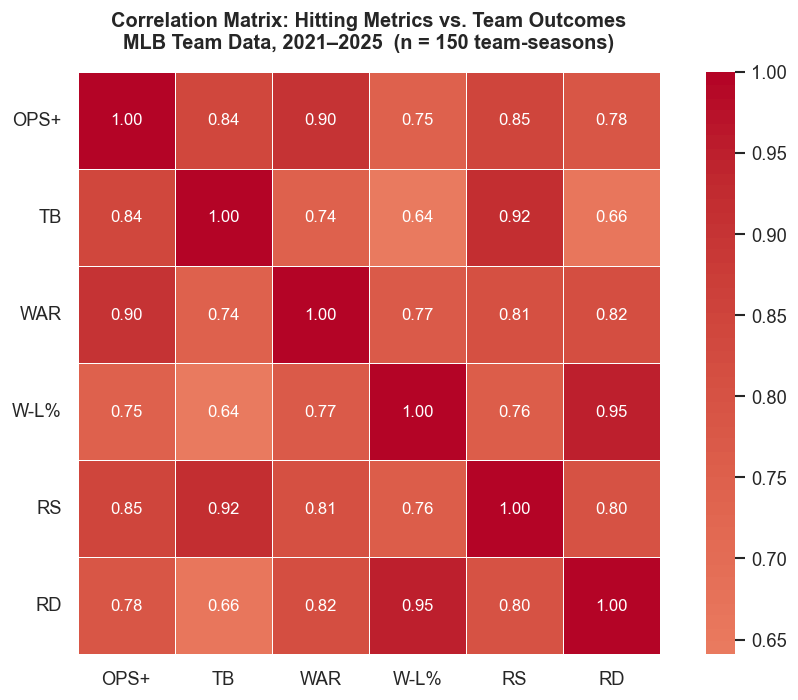


  Saved: correlation_heatmap.png


In [6]:
# 5. CORRELATION HEATMAP
corr = mlb[stat_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.6,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 10}
)
ax.set_title("Correlation Matrix: Hitting Metrics vs. Team Outcomes\nMLB Team Data, 2021–2025  (n = 150 team-seasons)",
             pad=14, fontweight="bold")
ax.set_xticklabels(["OPS+", "TB", "WAR", "W-L%", "RS", "RD"], rotation=0)
ax.set_yticklabels(["OPS+", "TB", "WAR", "W-L%", "RS", "RD"], rotation=0)
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("\n  Saved: correlation_heatmap.png")

Text(0.5, 1.01, 'MLB 2021–2025: Hitting Metrics vs. Team Outcomes\nEach point = one team-season  |  Line = OLS regression')

Text(0.5, 1.0, 'OPS+ vs W-L%\nr = 0.750,  p < 0.001')

Text(0.5, 0, 'OPS+')

Text(0, 0.5, 'W-L%')

Text(0.5, 1.0, 'OPS+ vs RS\nr = 0.846,  p < 0.001')

...

Text(0.5, 0, 'WAR')

Text(0, 0.5, 'RS')

Text(0.5, 1.0, 'WAR vs RD\nr = 0.818,  p < 0.001')

Text(0.5, 0, 'WAR')

Text(0, 0.5, 'RD')

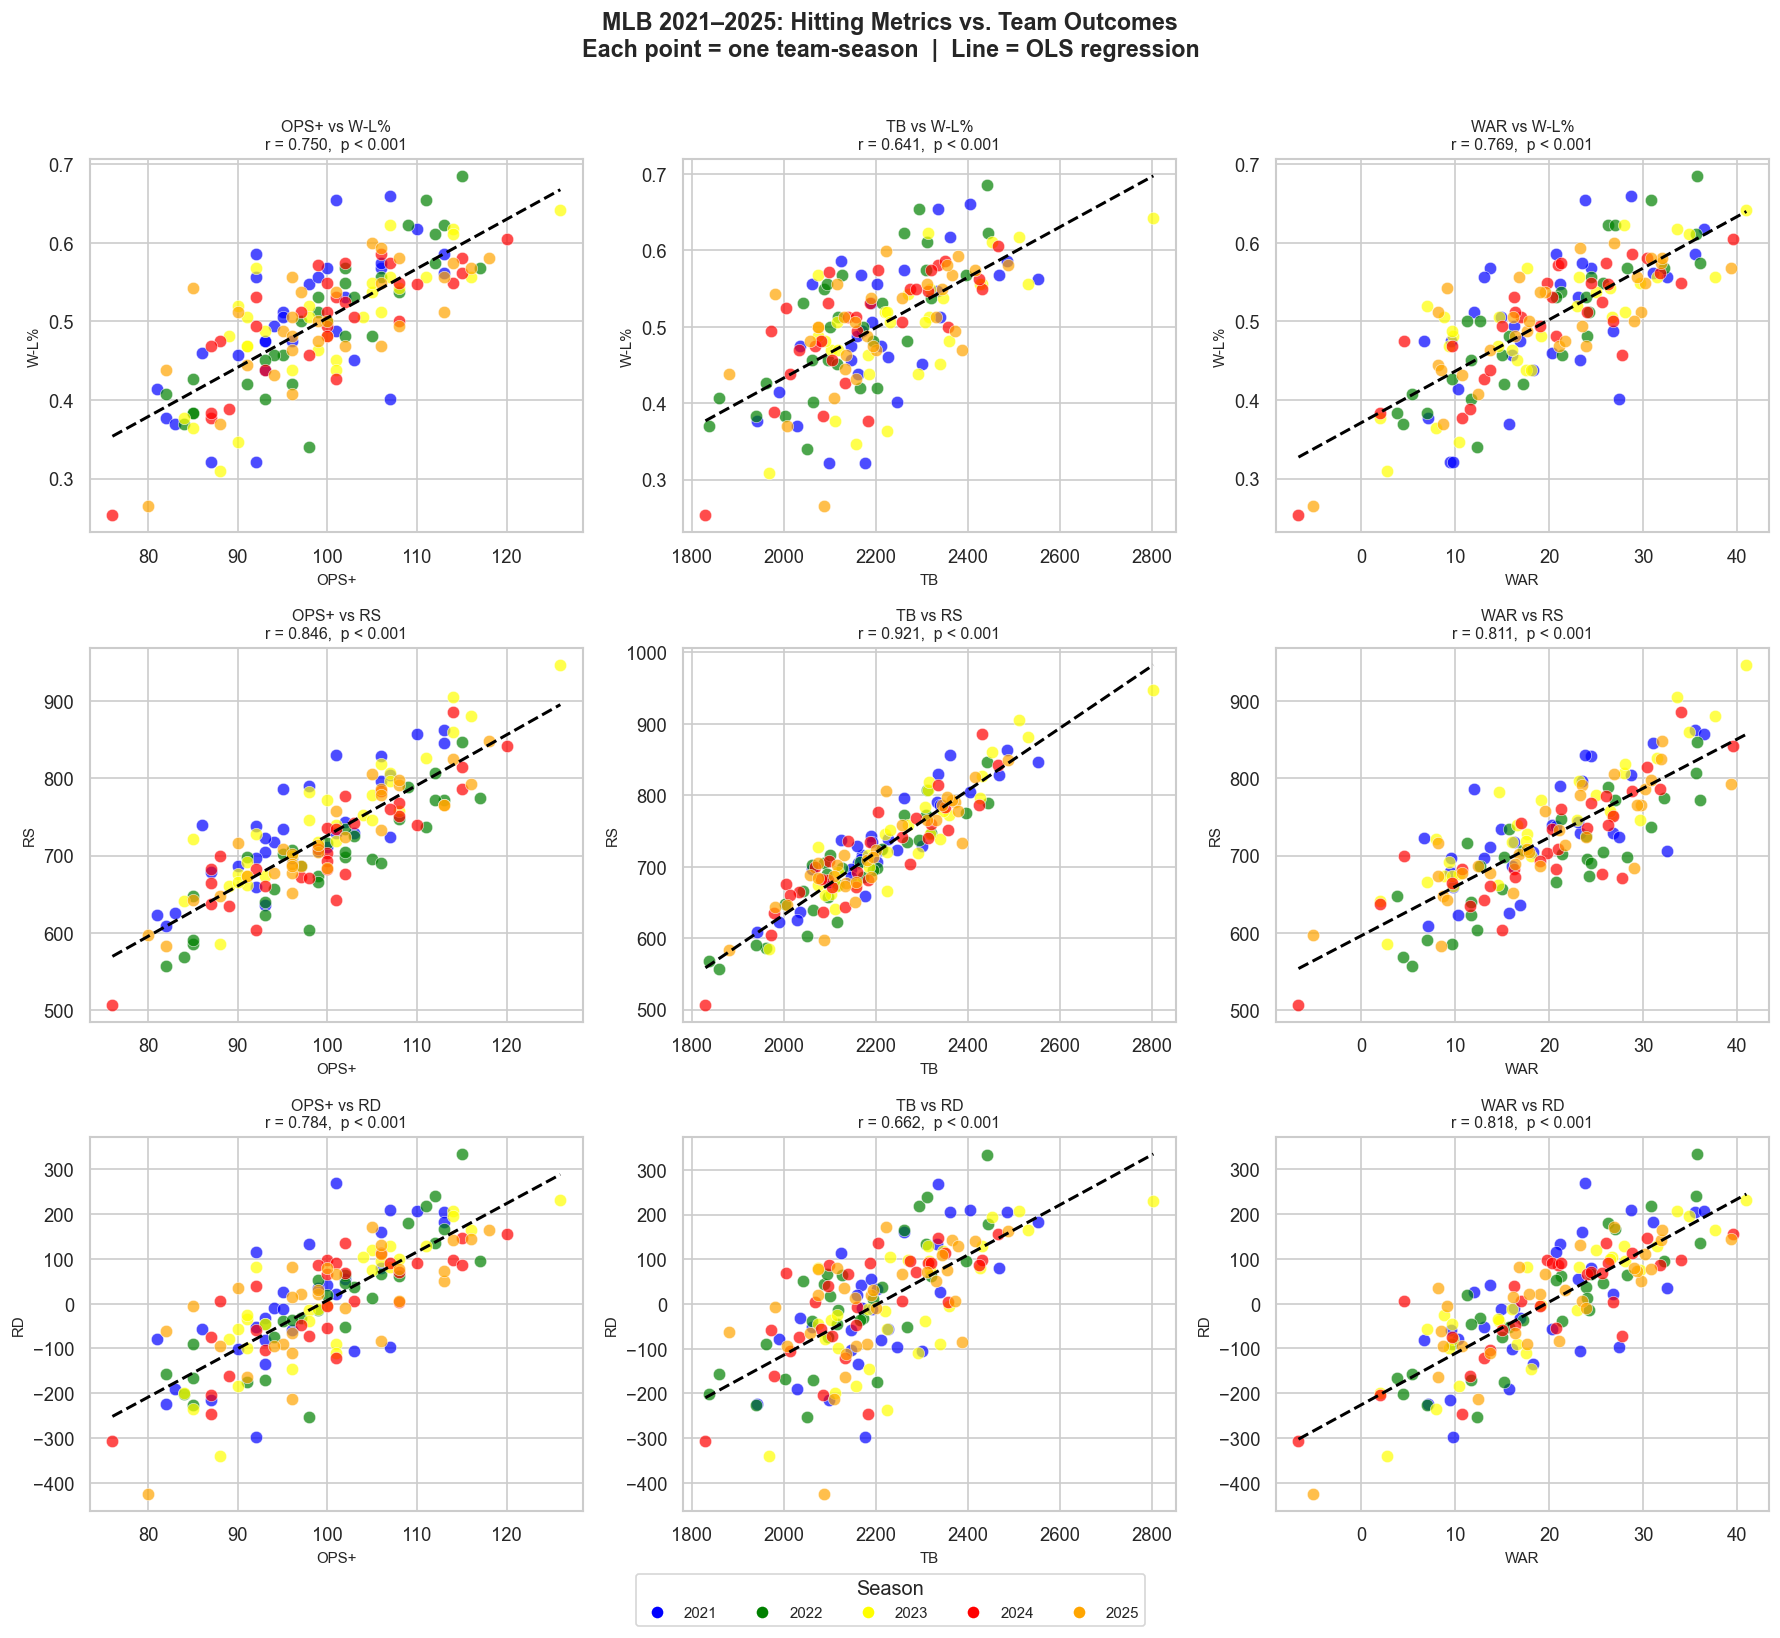

  Saved: scatter_regression_plots.png


In [7]:
# 6. SCATTER PLOTS WITH REGRESSION LINES  (3 predictors × 3 outcomes = 9 plots)
season_colors = {2021: "blue", 2022: "green",
                 2023: "yellow", 2024: "red", 2025: "orange"}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle(
    "MLB 2021–2025: Hitting Metrics vs. Team Outcomes\n"
    "Each point = one team-season  |  Line = OLS regression",
    fontsize=14, fontweight="bold", y=1.01
)

for col, (pred, plbl) in enumerate(zip(predictors, pred_labels)):
    for row, (out, olbl) in enumerate(zip(outcomes, out_labels)):
        ax = axes[row][col]
        data = mlb[[pred, out, "Season"]].dropna()

        # Scatter — colour-coded by season
        for yr, grp in data.groupby("Season"):
            ax.scatter(grp[pred], grp[out],
                       color=season_colors[yr], label=str(yr),
                       alpha=0.7, edgecolors="white", linewidth=0.4, s=55)

        # OLS regression line
        slope, intercept, r, p, _ = stats.linregress(data[pred], data[out])
        x_line = np.linspace(data[pred].min(), data[pred].max(), 200)
        ax.plot(x_line, slope * x_line + intercept,
                color="black", linewidth=1.8, linestyle="--")

        p_str = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.set_title(f"{plbl} vs {olbl}\nr = {r:.3f},  {p_str}", fontsize=9.5)
        ax.set_xlabel(plbl, fontsize=9)
        ax.set_ylabel(olbl, fontsize=9)

# Single shared legend for seasons (bottom centre)
handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=c, markersize=8, label=str(yr))
           for yr, c in season_colors.items()]
fig.legend(handles=handles, title="Season", loc="lower center",
           ncol=5, bbox_to_anchor=(0.5, -0.03), frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig("scatter_regression_plots.png", bbox_inches="tight")
plt.show()
print("  Saved: scatter_regression_plots.png")

SEASON-BY-SEASON TEAM AVERAGES
          OPS+       TB    WAR  W-L%      RS    RD
Season                                            
2021    97.000 2217.367 19.610 0.500 733.667 0.000
2022    99.767 2151.533 19.687 0.500 693.900 0.000
2023   100.000 2269.833 19.690 0.500 747.733 0.000
2024    99.900 2178.233 19.683 0.500 711.433 0.000
2025    99.867 2202.967 19.677 0.500 720.467 0.000


Text(0.5, 0.98, 'MLB Season-by-Season Team Averages (2021–2025)')

Text(0.5, 1.0, 'Mean OPS+')

Text(0.5, 0, 'Season')

Text(0, 0.5, 'Mean OPS+')

...

Text(0.5, 0, 'Season')

Text(0, 0.5, 'Mean RS')

Text(0.5, 1.0, 'Mean RD')

Text(0.5, 0, 'Season')

Text(0, 0.5, 'Mean RD')

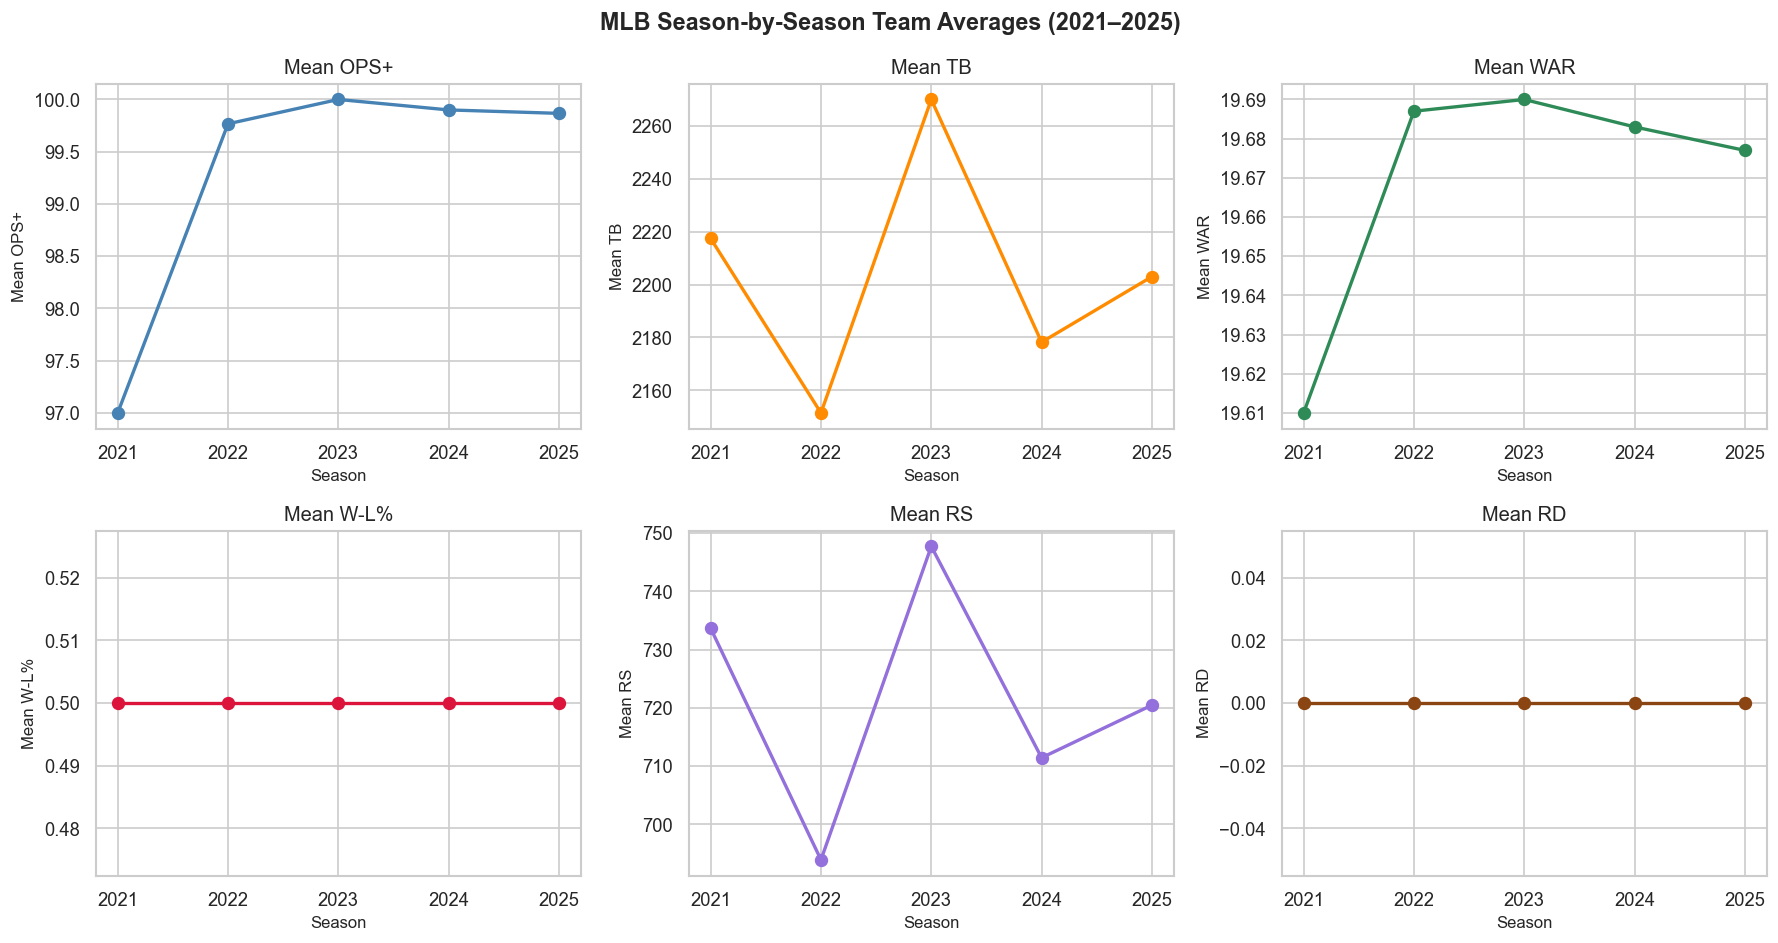

  Saved: season_trends.png


In [8]:
# 7. SEASON-BY-SEASON MEAN TRENDS  (line chart)
season_means = mlb.groupby("Season")[stat_cols].mean().round(3)

print("SEASON-BY-SEASON TEAM AVERAGES")
print(season_means.rename(columns={"OPS_plus": "OPS+", "WL_Pct": "W-L%"}).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("MLB Season-by-Season Team Averages (2021–2025)",
             fontsize=14, fontweight="bold")

plot_cols  = ["OPS_plus", "TB", "WAR", "WL_Pct", "RS", "RD"]
plot_lbls  = ["Mean OPS+", "Mean TB", "Mean WAR",
              "Mean W-L%", "Mean RS", "Mean RD"]
line_colors = ["steelblue", "darkorange", "seagreen",
               "crimson", "mediumpurple", "saddlebrown"]

for ax, col, lbl, clr in zip(axes.flat, plot_cols, plot_lbls, line_colors):
    ax.plot(season_means.index, season_means[col],
            marker="o", color=clr, linewidth=2, markersize=7)
    ax.set_title(lbl)
    ax.set_xlabel("Season")
    ax.set_ylabel(lbl)
    ax.set_xticks(years)

plt.tight_layout()
plt.savefig("season_trends.png", bbox_inches="tight")
plt.show()
print("  Saved: season_trends.png")